In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import plotly.express as px
from sklearn.metrics import silhouette_score

**Loading Data**

In [89]:
df = pd.read_csv('/content/Bullying_2018.csv', sep=';')

In [90]:
df.head(10)

,record,Bullied_on_school_property_in_past_12_months,Bullied_not_on_school_property_in_past_12_months,Cyber_bullied_in_past_12_months,Custom_Age,Sex,Physically_attacked,Physical_fighting,Felt_lonely,Close_friends,Miss_school_no_permission,Other_students_kind_and_helpful,Parents_understand_problems,Most_of_the_time_or_always_felt_lonely,Missed_classes_or_school_without_permission,Were_underweight,Were_overweight,Were_obese
0,1,Yes,Yes,,13 years old,Female,0 times,0 times,Always,2,10 or more days,Never,Always,Yes,Yes,,,
1,2,No,No,No,13 years old,Female,0 times,0 times,Never,3 or more,0 days,Sometimes,Always,No,No,,,
2,3,No,No,No,14 years old,Male,0 times,0 times,Never,3 or more,0 days,Sometimes,Always,No,No,No,No,No
3,4,No,No,No,16 years old,Male,0 times,2 or 3 times,Never,3 or more,0 days,Sometimes,,No,No,No,No,No
4,5,No,No,No,13 years old,Female,0 times,0 times,Rarely,3 or more,0 days,Most of the time,Most of the time,No,No,,,
5,6,No,No,No,13 years old,Male,0 times,1 time,Never,3 or more,0 days,Most of the time,Always,No,No,No,No,No
6,7,No,No,No,14 years old,Female,1 time,0 times,Sometimes,3 or more,0 days,Most of the time,Always,No,No,,,
7,8,No,No,No,12 years old,Female,0 times,0 times,Rarely,3 or more,0 days,Most of the time,Never,No,No,,,
8,9,No,No,No,13 years old,Male,1 time,2 or 3 times,Never,3 or more,6 to 9 days,Most of the time,Most of the time,No,Yes,,,
9,10,Yes,No,No,14 years old,Female,0 times,0 times,Always,0,0 days,Sometimes,Never,Yes,No,,,


**Data Understanding**

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56981 entries, 0 to 56980
Data columns (total 18 columns):
 #   Column                                            Non-Null Count  Dtype 
---  ------                                            --------------  ----- 
 0   record                                            56981 non-null  int64 
 1   Bullied_on_school_property_in_past_12_months      56981 non-null  object
 2   Bullied_not_on_school_property_in_past_12_months  56981 non-null  object
 3   Cyber_bullied_in_past_12_months                   56981 non-null  object
 4   Custom_Age                                        56981 non-null  object
 5   Sex                                               56981 non-null  object
 6   Physically_attacked                               56981 non-null  object
 7   Physical_fighting                                 56981 non-null  object
 8   Felt_lonely                                       56981 non-null  object
 9   Close_friends               

In [92]:
df.shape

(56981, 18)

In [93]:
df.isnull().sum()

,0
record,0
Bullied_on_school_property_in_past_12_months,0
Bullied_not_on_school_property_in_past_12_months,0
Cyber_bullied_in_past_12_months,0
Custom_Age,0
Sex,0
Physically_attacked,0
Physical_fighting,0
Felt_lonely,0
Close_friends,0


In [94]:
df['Were_overweight'].unique()

array([' ', 'No', 'Yes'], dtype=object)

In [95]:
df = df.replace(' ', np.nan)

In [96]:
df.isnull().sum()

,0
record,0
Bullied_on_school_property_in_past_12_months,1239
Bullied_not_on_school_property_in_past_12_months,489
Cyber_bullied_in_past_12_months,571
Custom_Age,108
Sex,536
Physically_attacked,240
Physical_fighting,268
Felt_lonely,366
Close_friends,1076


In [97]:
for col in df.columns:
  if col != 'record':
    print(df[col].value_counts(dropna=False))


Bullied_on_school_property_in_past_12_months
No     43839
Yes    11903
NaN     1239
Name: count, dtype: int64
Bullied_not_on_school_property_in_past_12_months
No     44263
Yes    12229
NaN      489
Name: count, dtype: int64
Cyber_bullied_in_past_12_months
No     44213
Yes    12197
NaN      571
Name: count, dtype: int64
Custom_Age
14 years old               12946
15 years old               12812
16 years old               11738
13 years old               10574
17 years old                8227
18 years old or older        383
12 years old                 145
NaN                          108
11 years old or younger       48
Name: count, dtype: int64
Sex
Female    29362
Male      27083
NaN         536
Name: count, dtype: int64
Physically_attacked
0 times             46997
1 time               5248
2 or 3 times         2405
12 or more times      790
4 or 5 times          695
6 or 7 times          302
NaN                   240
8 or 9 times          189
10 or 11 times        115
Name: count, 

**Preprocessing**

In [98]:
df_new = df.copy()

In [99]:
df_new.head()

,record,Bullied_on_school_property_in_past_12_months,Bullied_not_on_school_property_in_past_12_months,Cyber_bullied_in_past_12_months,Custom_Age,Sex,Physically_attacked,Physical_fighting,Felt_lonely,Close_friends,Miss_school_no_permission,Other_students_kind_and_helpful,Parents_understand_problems,Most_of_the_time_or_always_felt_lonely,Missed_classes_or_school_without_permission,Were_underweight,Were_overweight,Were_obese
0,1,Yes,Yes,NaN,13 years old,Female,0 times,0 times,Always,2,10 or more days,Never,Always,Yes,Yes,NaN,NaN,NaN
1,2,No,No,No,13 years old,Female,0 times,0 times,Never,3 or more,0 days,Sometimes,Always,No,No,NaN,NaN,NaN
2,3,No,No,No,14 years old,Male,0 times,0 times,Never,3 or more,0 days,Sometimes,Always,No,No,No,No,No
3,4,No,No,No,16 years old,Male,0 times,2 or 3 times,Never,3 or more,0 days,Sometimes,NaN,No,No,No,No,No
4,5,No,No,No,13 years old,Female,0 times,0 times,Rarely,3 or more,0 days,Most of the time,Most of the time,No,No,NaN,NaN,NaN


In [100]:
df_new = df_new.drop(columns=['record',
                 'Missed_classes_or_school_without_permission',
                 'Most_of_the_time_or_always_felt_lonely',
                 'Were_obese'])

In [101]:
df_new.shape

(56981, 14)

In [102]:
df_new = df_new.dropna()

In [103]:
df_new.shape

(32938, 14)

In [104]:
df_new.columns.tolist()

['Bullied_on_school_property_in_past_12_months',
 'Bullied_not_on_school_property_in_past_12_months',
 'Cyber_bullied_in_past_12_months',
 'Custom_Age',
 'Sex',
 'Physically_attacked',
 'Physical_fighting',
 'Felt_lonely',
 'Close_friends',
 'Miss_school_no_permission',
 'Other_students_kind_and_helpful',
 'Parents_understand_problems',
 'Were_underweight',
 'Were_overweight']

In [105]:
df_new = df_new.rename(columns={
    'Bullied_on_school_property_in_past_12_months': 'bullied_school',
    'Bullied_not_on_school_property_in_past_12_months': 'bullied_outside',
    'Cyber_bullied_in_past_12_months': 'cyber_bullied',
    'Custom_Age': 'age',
    'Sex': 'sex',
    'Physically_attacked': 'physically_attacked',
    'Physical_fighting': 'physical_fighting',
    'Felt_lonely': 'felt_lonely',
    'Close_friends': 'close_friends',
    'Miss_school_no_permission': 'missed_school',
    'Other_students_kind_and_helpful': 'students_kind',
    'Parents_understand_problems': 'parents_understand',
    'Were_underweight': 'underweight',
    'Were_overweight': 'overweight'
})

In [106]:
df_new.head()

,bullied_school,bullied_outside,cyber_bullied,age,sex,physically_attacked,physical_fighting,felt_lonely,close_friends,missed_school,students_kind,parents_understand,underweight,overweight
2,No,No,No,14 years old,Male,0 times,0 times,Never,3 or more,0 days,Sometimes,Always,No,No
5,No,No,No,13 years old,Male,0 times,1 time,Never,3 or more,0 days,Most of the time,Always,No,No
10,No,No,No,15 years old,Male,0 times,1 time,Never,3 or more,3 to 5 days,Most of the time,Always,No,No
22,No,No,Yes,13 years old,Male,0 times,2 or 3 times,Most of the time,3 or more,0 days,Rarely,Always,No,No
23,No,No,No,14 years old,Male,0 times,2 or 3 times,Most of the time,2,0 days,Always,Sometimes,No,Yes


#Encoding

In [107]:
df_new.nunique()

,0
bullied_school,2
bullied_outside,2
cyber_bullied,2
age,8
sex,2
physically_attacked,8
physical_fighting,8
felt_lonely,5
close_friends,4
missed_school,5


*Mapping*


In [108]:
df_new['bullied_school'] = df_new['bullied_school'].map({'Yes':1, 'No': 0})
df_new['bullied_outside'] = df_new['bullied_outside'].map({'Yes':1, 'No': 0})
df_new['cyber_bullied'] = df_new['cyber_bullied'].map({'Yes':1, 'No': 0})

In [109]:
df_new['age'].head()

,age
2,14 years old
5,13 years old
10,15 years old
22,13 years old
23,14 years old


In [110]:
df_new['age'] = df_new['age'].str.extract('(\d+)').astype(int)

In [111]:
df_new['sex'] = df_new['sex'].map({'Female':0, 'Male':1})

In [112]:
df_new['physically_attacked'].unique()

array(['0 times', '1 time', '4 or 5 times', '10 or 11 times',
       '2 or 3 times', '12 or more times', '6 or 7 times', '8 or 9 times'],
      dtype=object)

In [113]:
df_new['physically_attacked'] = df_new['physically_attacked'].map({
    '0 times': 0, '1 time': 1, '2 or 3 times': 2, '4 or 5 times': 4,
    '6 or 7 times': 6, '8 or 9 times': 8, '10 or 11 times': 10, '12 or more times': 12
})

In [114]:
df_new['physical_fighting'].unique()

array(['0 times', '1 time', '2 or 3 times', '8 or 9 times',
       '4 or 5 times', '6 or 7 times', '10 or 11 times',
       '12 or more times'], dtype=object)

In [115]:
df_new['physical_fighting'] = df_new['physical_fighting'].map({'0 times' : 0, '1 time' : 1, '2 or 3 times' : 2, '8 or 9 times' : 8,
       '4 or 5 times' : 4, '6 or 7 times' : 6 , '10 or 11 times' : 10,
       '12 or more times' : 12})

In [116]:
df_new['felt_lonely'].unique()

array(['Never', 'Most of the time', 'Rarely', 'Sometimes', 'Always'],
      dtype=object)

In [117]:
df_new['felt_lonely'] = df_new['felt_lonely'].map({
    'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Most of the time': 3, 'Always': 4
})

*Get Dummies*

In [118]:
df_new['close_friends'].unique()

array(['3 or more', '2', '0', '1'], dtype=object)

In [119]:
df_new['close_friends'] = df_new['close_friends'].map({'3 or more' : 3, '2' : 2, '0' : 0, '1' : 1})

In [120]:
df_new['missed_school'].unique()

array(['0 days', '3 to 5 days', '10 or more days', '1 or 2 days',
       '6 to 9 days'], dtype=object)

In [121]:
df_new['missed_school'] = df_new['missed_school'].map({'0 days' : 0, '3 to 5 days' : 4, '10 or more days' : 10, '1 or 2 days': 1,
                                                    '6 to 9 days' : 7})

In [122]:
df_new['students_kind'].unique()

array(['Sometimes', 'Most of the time', 'Rarely', 'Always', 'Never'],
      dtype=object)

In [123]:
df_new['students_kind'] = df_new['students_kind'].map({
    'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Most of the time': 3, 'Always': 4
})

In [124]:
df_new['parents_understand'].unique()

array(['Always', 'Sometimes', 'Rarely', 'Most of the time', 'Never'],
      dtype=object)

In [125]:
df_new['parents_understand'] = df_new['parents_understand'].map({
    'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Most of the time': 3, 'Always': 4
})

In [126]:
df_new['underweight'] = df_new['underweight'].map({'Yes' : 1, 'No' : 0})
df_new['overweight'] = df_new['overweight'].map({'Yes' : 1, 'No' : 0})

In [127]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32938 entries, 2 to 56980
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   bullied_school       32938 non-null  int64
 1   bullied_outside      32938 non-null  int64
 2   cyber_bullied        32938 non-null  int64
 3   age                  32938 non-null  int64
 4   sex                  32938 non-null  int64
 5   physically_attacked  32938 non-null  int64
 6   physical_fighting    32938 non-null  int64
 7   felt_lonely          32938 non-null  int64
 8   close_friends        32938 non-null  int64
 9   missed_school        32938 non-null  int64
 10  students_kind        32938 non-null  int64
 11  parents_understand   32938 non-null  int64
 12  underweight          32938 non-null  int64
 13  overweight           32938 non-null  int64
dtypes: int64(14)
memory usage: 3.8 MB


**EDA**

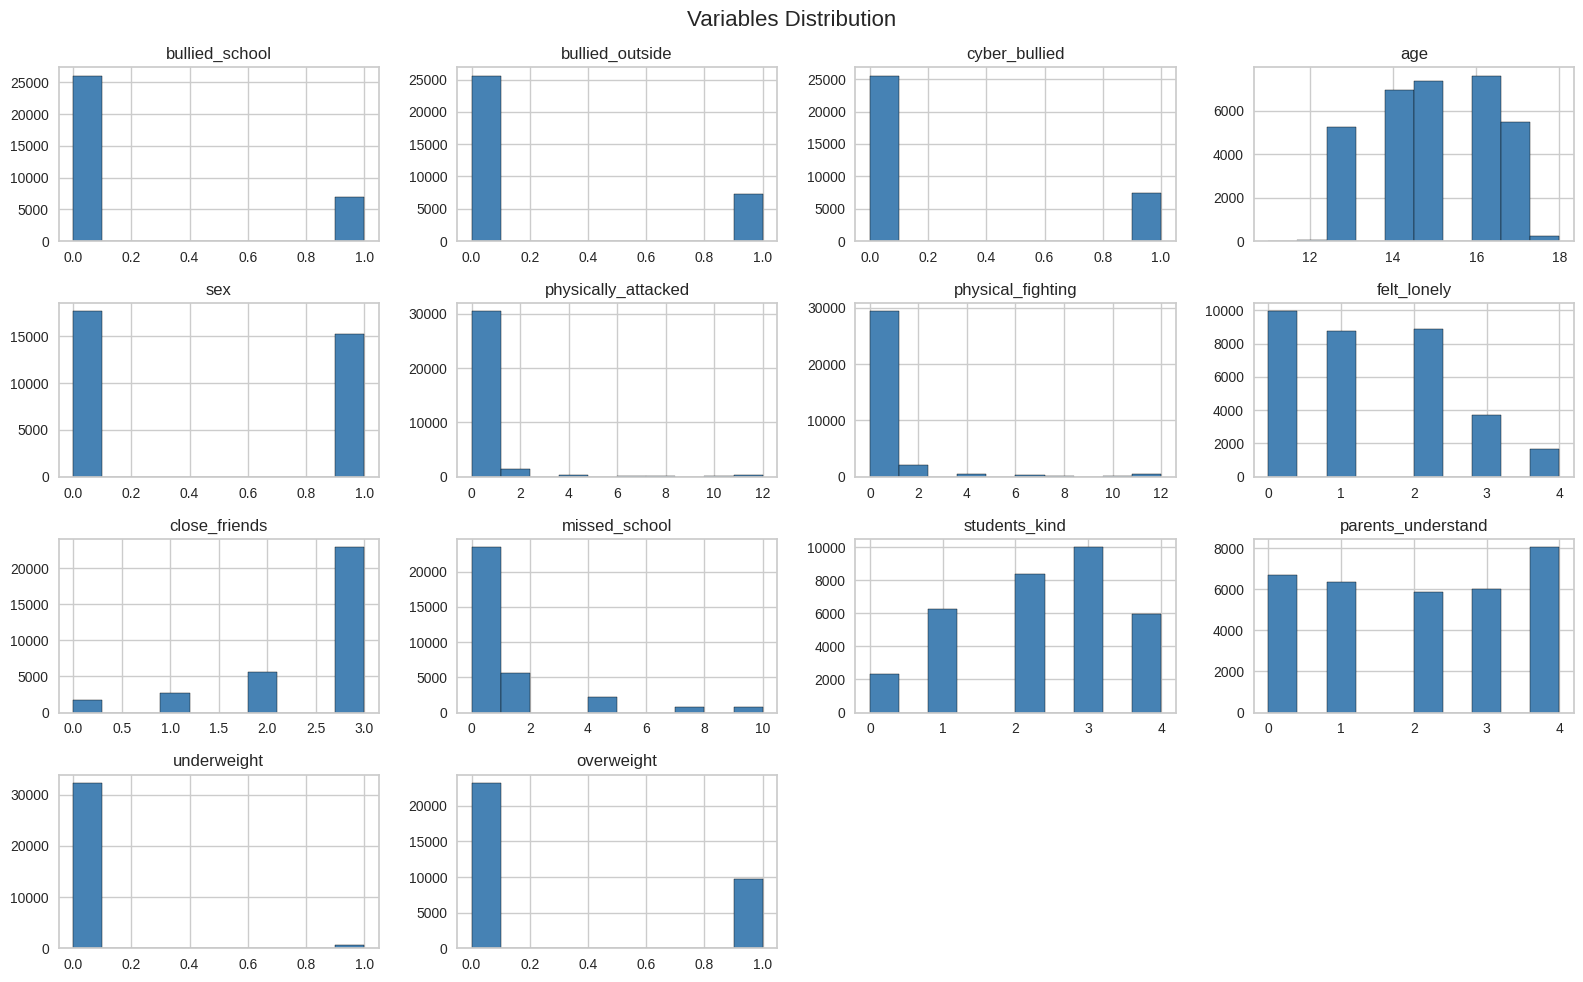

In [128]:
df_new.hist(figsize=(16, 10), bins=10, color='steelblue', edgecolor='black')
plt.suptitle('Variables Distribution', fontsize=16)
plt.tight_layout()
plt.show()

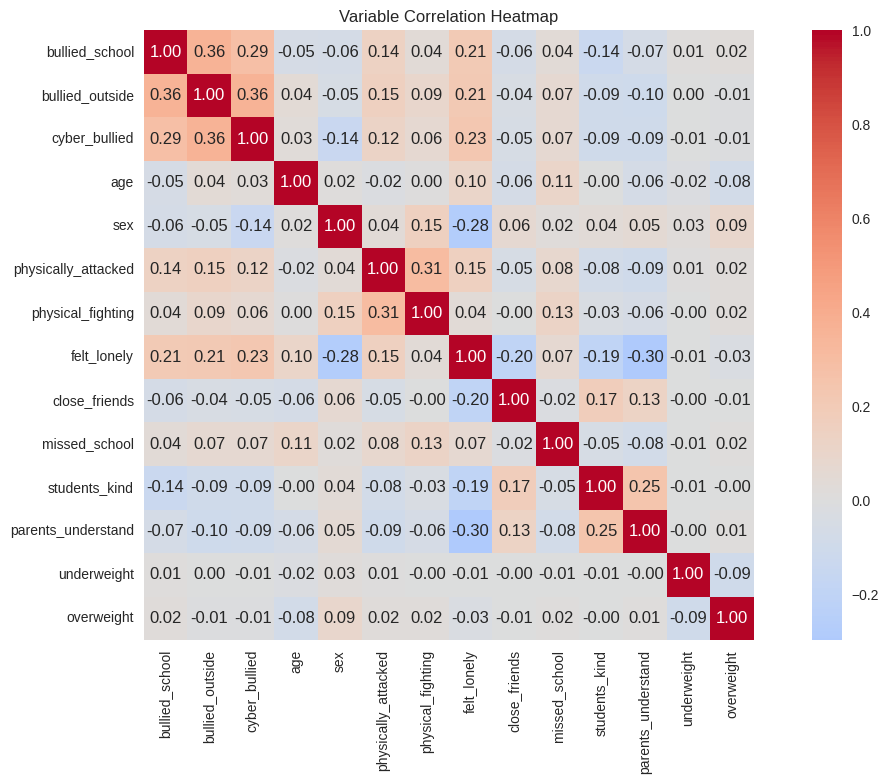

In [129]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_new.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True)
plt.title('Variable Correlation Heatmap')
plt.tight_layout()
plt.show()

In [130]:
df_new = df_new.drop(columns='underweight')

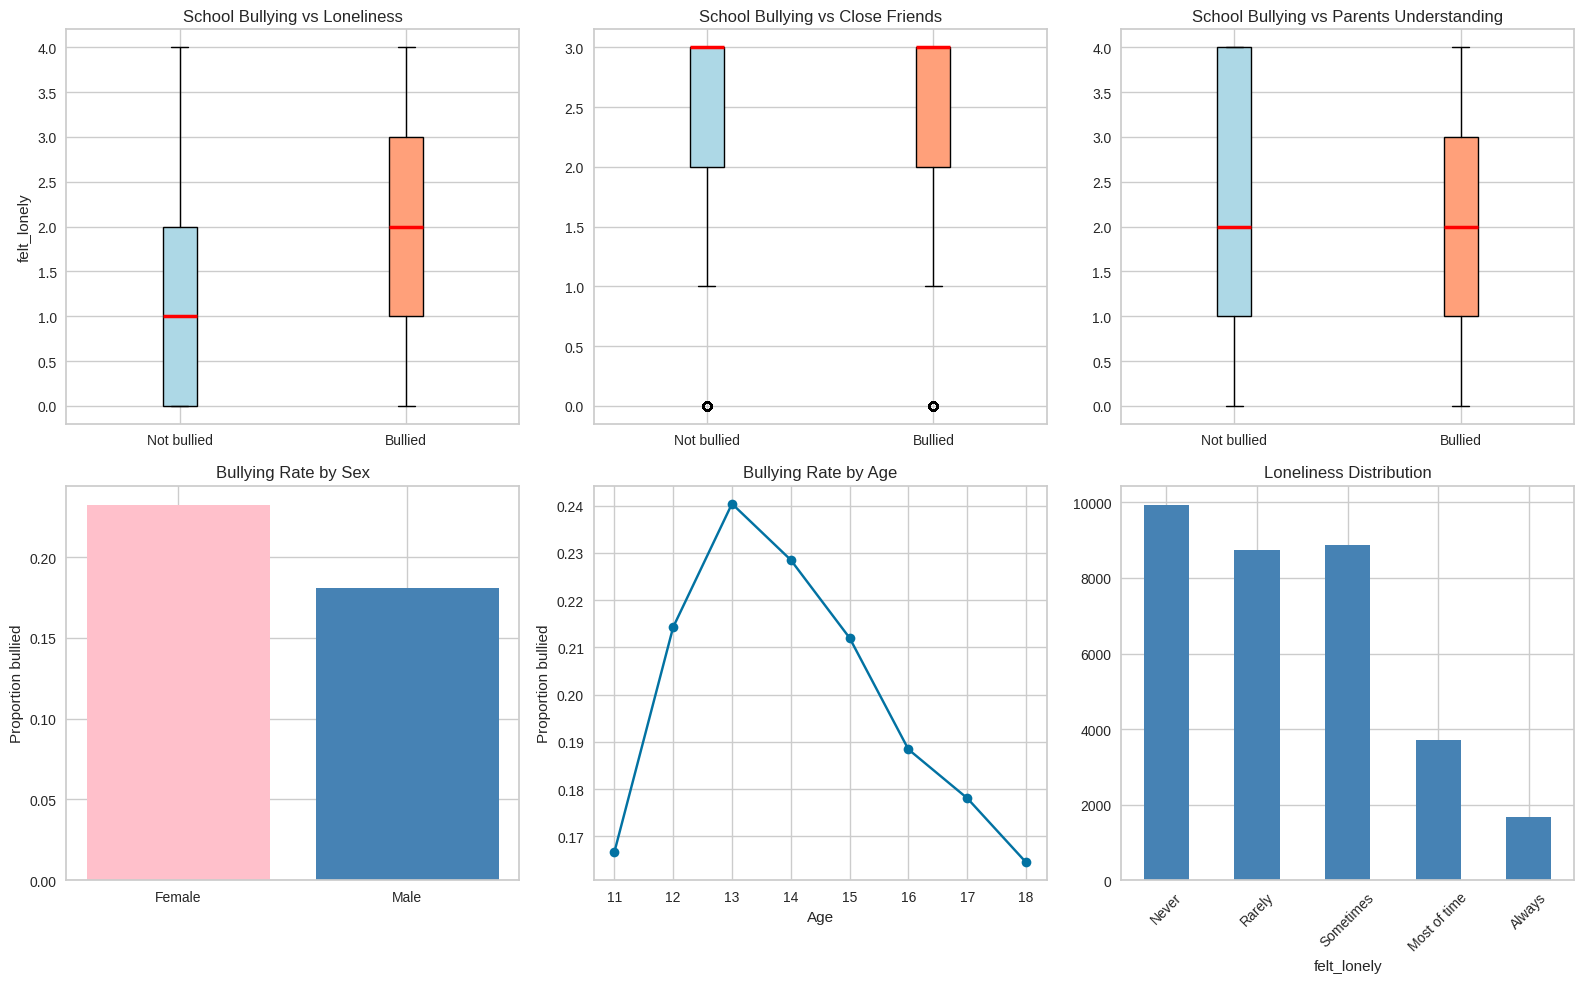

In [131]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

median_props = dict(color='red', linewidth=2.5)
box_colors = ['lightblue', 'lightsalmon']

bp1 = axes[0,0].boxplot([df_new[df_new['bullied_school']==0]['felt_lonely'],
                          df_new[df_new['bullied_school']==1]['felt_lonely']],
                          labels=['Not bullied', 'Bullied'],
                          patch_artist=True, medianprops=median_props)
for patch, color in zip(bp1['boxes'], box_colors):
    patch.set_facecolor(color)
axes[0,0].set_title('School Bullying vs Loneliness')
axes[0,0].set_ylabel('felt_lonely')

bp2 = axes[0,1].boxplot([df_new[df_new['bullied_school']==0]['close_friends'],
                          df_new[df_new['bullied_school']==1]['close_friends']],
                          labels=['Not bullied', 'Bullied'],
                          patch_artist=True, medianprops=median_props)
for patch, color in zip(bp2['boxes'], box_colors):
    patch.set_facecolor(color)
axes[0,1].set_title('School Bullying vs Close Friends')

bp3 = axes[0,2].boxplot([df_new[df_new['bullied_school']==0]['parents_understand'],
                          df_new[df_new['bullied_school']==1]['parents_understand']],
                          labels=['Not bullied', 'Bullied'],
                          patch_artist=True, medianprops=median_props)
for patch, color in zip(bp3['boxes'], box_colors):
    patch.set_facecolor(color)
axes[0,2].set_title('School Bullying vs Parents Understanding')

sex_bull = df_new.groupby('sex')['bullied_school'].mean()
axes[1,0].bar(['Female', 'Male'], sex_bull.values, color=['pink', 'steelblue'])
axes[1,0].set_title('Bullying Rate by Sex')
axes[1,0].set_ylabel('Proportion bullied')

age_bull = df_new.groupby('age')['bullied_school'].mean()
axes[1,1].plot(age_bull.index, age_bull.values, 'bo-')
axes[1,1].set_title('Bullying Rate by Age')
axes[1,1].set_xlabel('Age')
axes[1,1].set_ylabel('Proportion bullied')

df_new['felt_lonely'].value_counts().sort_index().plot(kind='bar', ax=axes[1,2], color='steelblue')
axes[1,2].set_title('Loneliness Distribution')
axes[1,2].set_xticklabels(['Never','Rarely','Sometimes','Most of time','Always'], rotation=45)

plt.tight_layout()
plt.show()

#Scaling

In [132]:
columns = df_new.columns

In [133]:
ss = StandardScaler()

In [134]:
df_new = ss.fit_transform(df_new)

In [135]:
df_new = pd.DataFrame(df_new, columns=columns)

#PCA

In [136]:
pca = PCA()

In [137]:
df_pca = pca.fit_transform(df_new)

In [138]:
pca.explained_variance_ratio_

array([0.17497869, 0.10855441, 0.09850107, 0.08603724, 0.07635934,
       0.07122337, 0.06890374, 0.06526079, 0.05642742, 0.05430615,
       0.05008164, 0.0459351 , 0.04343103])

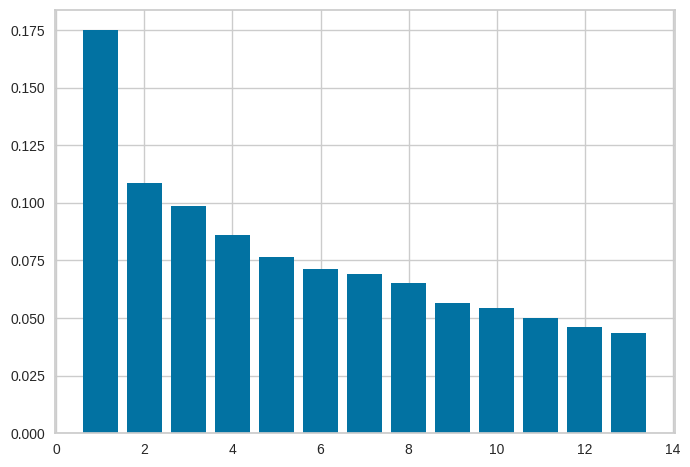

In [139]:
plt.bar(range(1, len(pca.explained_variance_ratio_) +1), pca.explained_variance_ratio_)
plt.show()

In [140]:
print('Percentage of cumulative variance of PCs', pca.explained_variance_ratio_.cumsum()*100)

Percentage of cumulative variance of PCs [ 17.49786917  28.35331004  38.2034167   46.80714042  54.44307429
  61.56541148  68.45578559  74.98186487  80.62460702  86.05522242
  91.06338667  95.65689664 100.        ]


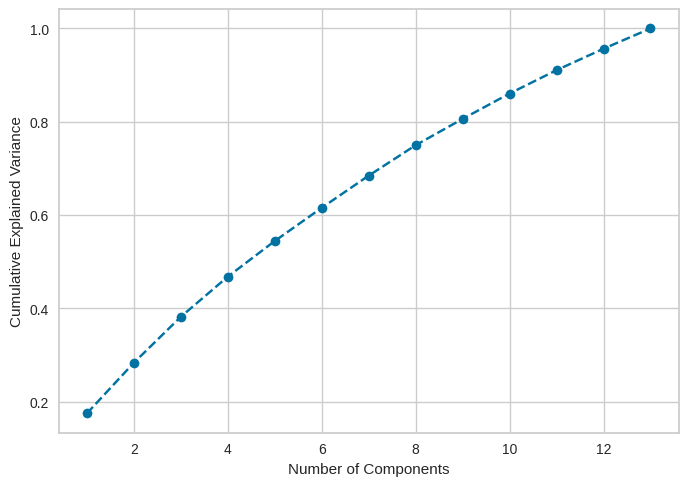

In [141]:
plt.plot(range(1, pca.n_components_+1), np.cumsum(pca.explained_variance_ratio_), marker = 'o', linestyle = '--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

In [142]:
pca = PCA(n_components=7)
df_pca = pca.fit_transform(df_new)
df_pca = pd.DataFrame(df_pca, columns=['PC1','PC2','PC3','PC4','PC5','PC6','PC7'], index=df_new.index)

In [143]:
df_pca.shape

(32938, 7)

In [144]:
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,-1.966060,0.481424,0.459117,-0.293863,-0.310759,1.000300,0.414441
1,-2.175100,0.959982,0.828101,-0.422726,-0.773503,0.574696,0.296712
2,-1.781147,1.245023,-0.077767,1.211774,0.405385,-0.011243,0.571442
3,0.433209,0.507195,0.686698,-0.616535,-0.922469,0.406981,0.493534
4,-0.546305,0.748538,-0.491168,-1.102341,0.263675,-1.032012,-1.209186


#Elbow Method

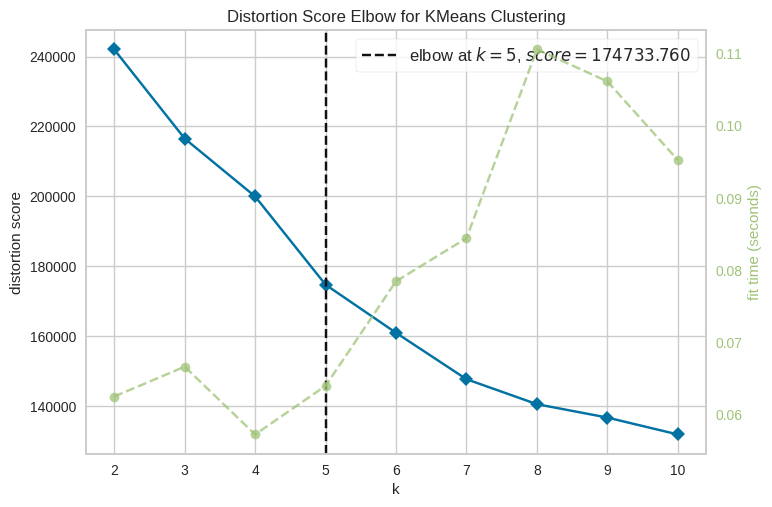

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [145]:
Elbow = KElbowVisualizer(estimator=KMeans(), k=10)
Elbow.fit(df_pca)
Elbow.show()

K=2: 0.2361
K=3: 0.2240
K=4: 0.1682
K=5: 0.1712
K=6: 0.1669
K=7: 0.1772
K=8: 0.1655
K=9: 0.1646
K=10: 0.1556


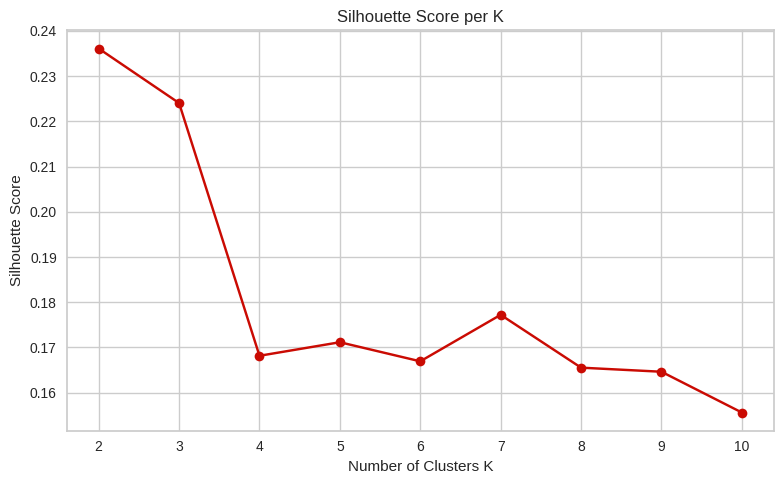

In [146]:
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pca)
    silhouette_scores.append(silhouette_score(df_pca, kmeans.labels_))
    print(f"K={k}: {silhouette_score(df_pca, kmeans.labels_):.4f}")

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score per K')
plt.tight_layout()
plt.show()

#KMeans

In [147]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

In [148]:
kmeans.fit(df_pca)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [149]:
df_pca['Cluster'] = kmeans.labels_

In [150]:
df_new['Cluster'] = kmeans.labels_.tolist()

In [151]:
print(f"Clusters Distribution:", df_new['Cluster'].value_counts())

Clusters Distribution: Cluster
1    22275
0     9350
2     1313
Name: count, dtype: int64


In [152]:
print(f"\nPercentage:", (df_new['Cluster'].value_counts() / len(df_new) * 100).round(2))


Percentage: Cluster
1    67.63
0    28.39
2     3.99
Name: count, dtype: float64


In [153]:
df_pca['Cluster'] = df_new['Cluster']

In [154]:
fig = px.scatter_3d(df_pca, x='PC1', y='PC2', z='PC3',
                    color=df_pca['Cluster'].astype(str),
                    title='PCA (3D)',
                    opacity=0.5,
                    labels={'color': 'Cluster'})
fig.update_traces(marker=dict(size=2))
fig.show()

#statistics on df intial

In [155]:
cluster_analysis = df_new.groupby('Cluster').mean().round(3)

In [156]:
print(cluster_analysis.T)

Cluster                  0      1      2
bullied_school       0.853 -0.376  0.306
bullied_outside      0.917 -0.411  0.441
cyber_bullied        0.905 -0.398  0.317
age                  0.098 -0.040 -0.022
sex                 -0.350  0.124  0.394
physically_attacked -0.008 -0.190  3.286
physical_fighting   -0.108 -0.159  3.471
felt_lonely          0.679 -0.311  0.438
close_friends       -0.253  0.117 -0.178
missed_school        0.147 -0.094  0.547
students_kind       -0.378  0.172 -0.224
parents_understand  -0.358  0.168 -0.310
overweight          -0.044  0.013  0.104


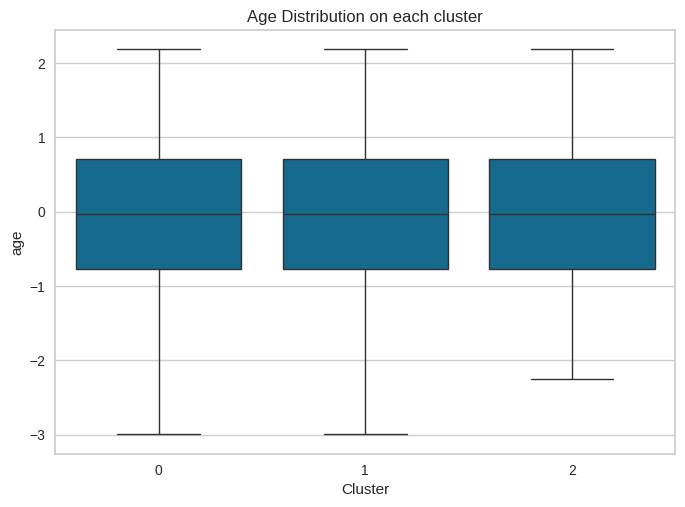

In [157]:
sns.boxplot(x='Cluster', y='age', data=df_new)
plt.title('Age Distribution on each cluster')
plt.show()

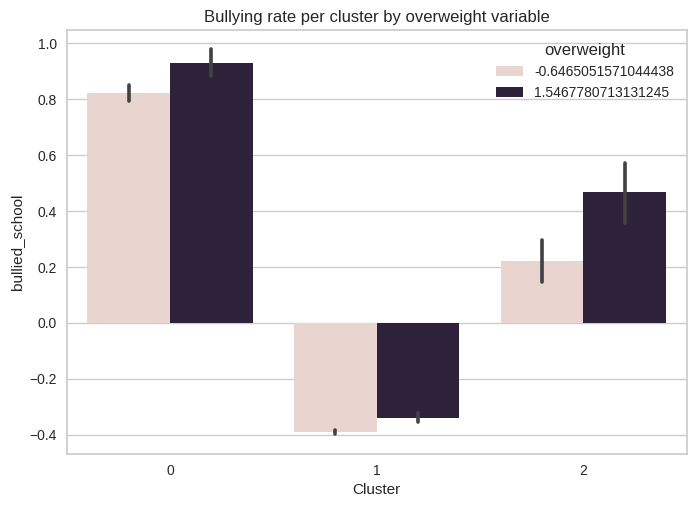

In [158]:
sns.barplot(x='Cluster', y='bullied_school', hue='overweight', data=df_new)
plt.title('Bullying rate per cluster by overweight variable')
plt.show()

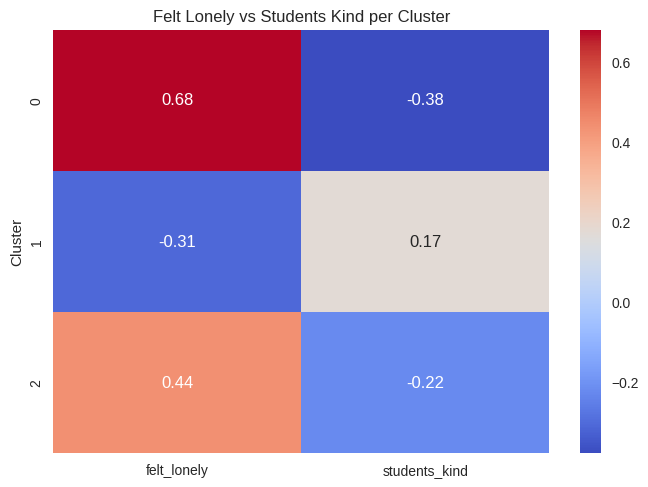

In [159]:
sns.heatmap(df_new.groupby('Cluster')[['felt_lonely', 'students_kind']].mean(),
            annot=True, cmap='coolwarm')
plt.title('Felt Lonely vs Students Kind per Cluster')
plt.show()

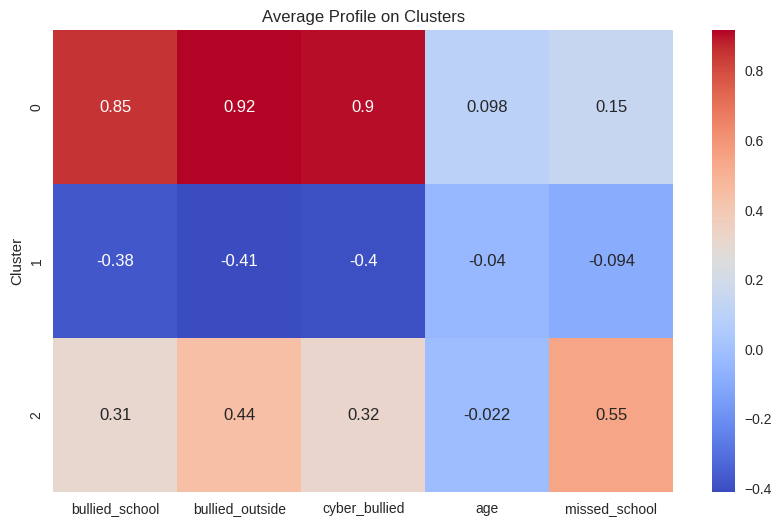

In [160]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_new.groupby('Cluster')[['bullied_school', 'bullied_outside',
            'cyber_bullied', 'age', 'missed_school']].mean(),
            annot=True, cmap='coolwarm')
plt.title('Average Profile on Clusters')
plt.show()

Check the quality of clusterning
⚙️ Interpretare:

0.7–1.0 → Clustere foarte bine separate

0.5–0.7 → Bine

0.25–0.5 → Slab/moderat

<0.25 → Probabil clustere neclare

In [161]:
silhouette_avg = silhouette_score(df_pca, df_new['Cluster'])
print(f"Silhouette Score: {silhouette_avg:.3f}")

Silhouette Score: 0.246


Checking the balance of clusters

In [162]:
df_new['Cluster'].value_counts()

,count
Cluster,
1,22275
0,9350
2,1313


Comparative Analysis on cluster 2
*   Check if it's an ''extreme group'' or an arthefact








In [163]:
df_new.groupby('Cluster')[['bullied_school', 'physical_fighting', 'missed_school', 'felt_lonely']].mean()

,bullied_school,physical_fighting,missed_school,felt_lonely
Cluster,,,,
0,0.852857,-0.108037,0.147224,0.679208
1,-0.376016,-0.159233,-0.094024,-0.310919
2,0.305822,3.470720,0.546723,0.438020


In [164]:
df_new.groupby('Cluster')[['cyber_bullied', 'parents_understand', 'students_kind', 'overweight']].mean()

,cyber_bullied,parents_understand,students_kind,overweight
Cluster,,,,
0,0.904706,-0.357554,-0.377627,-0.044349
1,-0.398467,0.168357,0.171700,0.012514
2,0.317484,-0.309998,-0.223764,0.103521


Labels per clusters

In [165]:
cluster_labels = {
    0: 'Bullied & Isolated',
    1: 'Well-Adjusted',
    2: 'Violent & Disengaged'
}

In [166]:
df_new['Cluster_Label'] = df_new['Cluster'].map(cluster_labels)

In [167]:
print(df_new['Cluster_Label'].value_counts())

Cluster_Label
Well-Adjusted           22275
Bullied & Isolated       9350
Violent & Disengaged     1313
Name: count, dtype: int64


Cluster Interpretation Summary:
- Cluster 0 (Bullied & Isolated - 28.4%): Students experiencing bullying on all levels
  (school, outside, cyber). High loneliness, low parental support, unkind peers.
  These are the victims - highest risk group requiring immediate intervention.

- Cluster 1 (Well-Adjusted - 67.5%): The majority group. Not bullied, emotionally stable,
  socially connected, supportive parents and kind peers. Low risk.

- Cluster 2 (Violent & Disengaged - 4.0%): Small but extreme group. Very high physical
  violence (attacked & fighting), high absenteeism, predominantly male.
  Likely the aggressors - require behavioral intervention.

Silhouette Score: 0.246 - Moderate cluster separation, typical for social survey data.

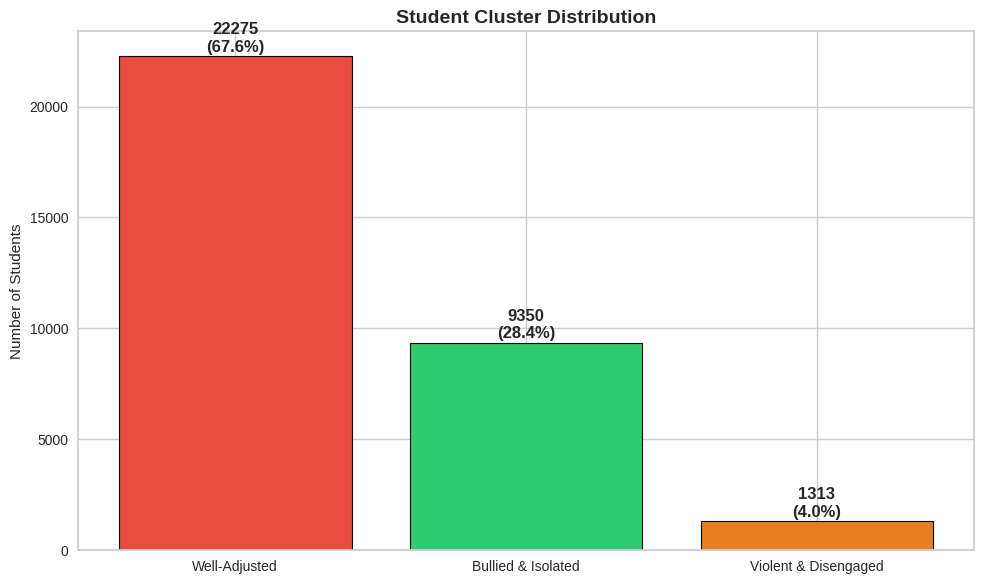

In [168]:
plt.figure(figsize=(10, 6))
colors = ['#e74c3c', '#2ecc71', '#e67e22']
counts = df_new['Cluster_Label'].value_counts()

bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{val}\n({val/len(df_new)*100:.1f}%)',
             ha='center', fontweight='bold')

plt.title('Student Cluster Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

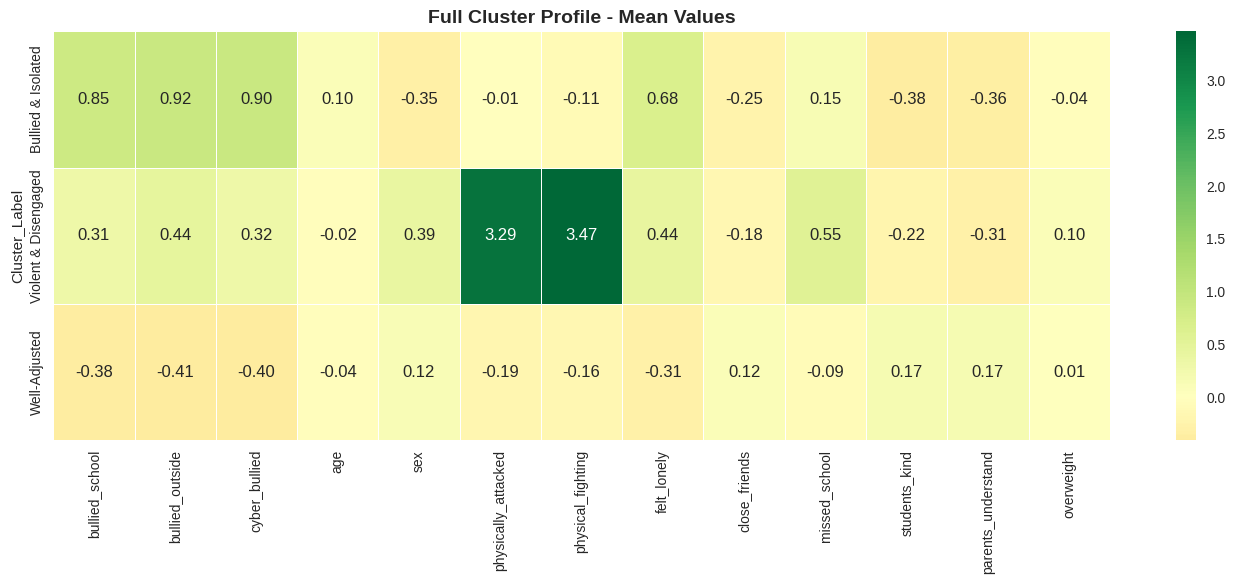

In [169]:
plt.figure(figsize=(14, 6))
cluster_means = df_new.groupby('Cluster_Label').mean().drop(columns='Cluster')
sns.heatmap(cluster_means, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, center=0)
plt.title('Full Cluster Profile - Mean Values', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()